 # notebook drive_me_crazy_tradi

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Run the notebook containing dataset analysis
%run dataset_analysis.ipynb

=== ANALYSE DONNÉES PeMS ===
Shape: (1501, 3)
Colonnes: ['from', 'to', 'cost']

Aperçu des données:
   from   to   cost
0    73    5  352.6
1     5  154  347.2
2   154  263  392.9
3   263   56  440.8
4    56   96  374.6

📊 Statistiques descriptives:
              from           to         cost
count  1501.000000  1501.000000  1501.000000
mean    305.879414   303.468354   155.867951
std     257.442896   256.217595   240.138476
min       0.000000     0.000000     0.032000
25%      97.000000    95.000000     0.809000
50%     217.000000   215.000000     2.252000
75%     505.000000   498.000000   335.700000
max     882.000000   882.000000  3274.400000

🔍 Valeurs manquantes:
from    0
to      0
cost    0
dtype: int64

📈 Analyse du réseau routier:
Nombre de nœuds (capteurs): 883
Nombre d'arêtes (routes): 1477
Densité du graphe: 0.0038


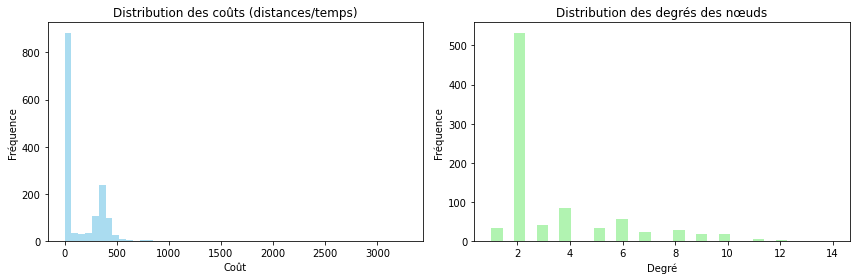

=== ANALYSE DONNÉES NYC Taxi ===
Shape: (228745, 11)
Colonnes: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']

Aperçu des données:
          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -73.999481   
2                1        -73.979027        40.763939         -74.005333   


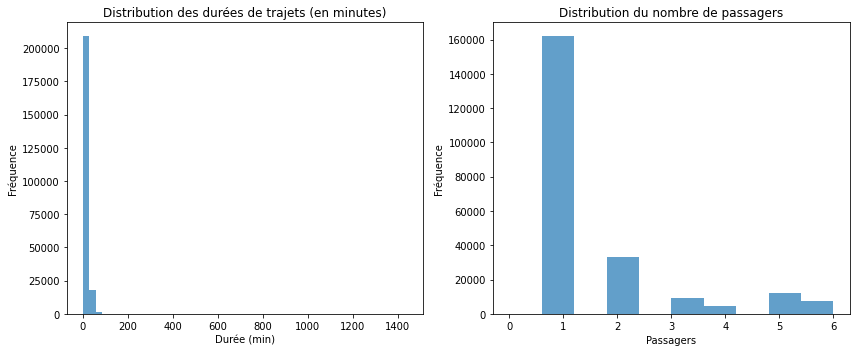


=== FEATURE ENGINEERING PeMS ===
Colonnes trouvées : ['from', 'to', 'cost']
Nodes: 883
Edges: 1477
Graph density: 0.0038

Aperçu avec nouvelles features :
   from   to   cost  from_degree  to_degree  from_centrality  to_centrality
0    73    5  352.6            5          7         0.006903       0.010151
1     5  154  347.2            7          8         0.010151       0.013020
2   154  263  392.9            8          4         0.013020       0.004067
3   263   56  440.8            4          6         0.004067       0.008989
4    56   96  374.6            6          7         0.008989       0.013302

=== FEATURE ENGINEERING NYC Taxi ===

Aperçu avec nouvelles features :
   distance_km  hour  weekday  month  is_weekend  trip_duration_min
0     1.498521    17        0      3           0           7.583333
1     1.805507     0        6      6           1          11.050000
2     6.385098    11        1      1           0          35.400000
3     1.485498    19        2      4        

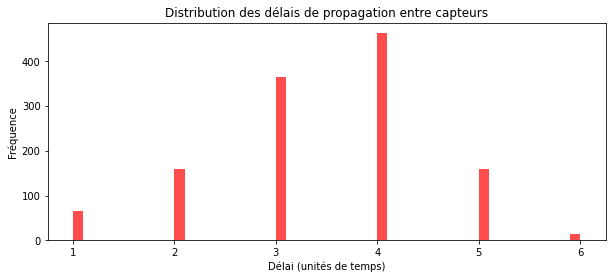

Délai moyen de propagation: 3.43
Délai max de propagation: 6.00

=== INTÉGRATION DES DONNÉES ===
Intégration terminée - Datasets prêts pour l'analyse combinée

 
A traditional traffic flow prediction model.

✔ After cleaning NaN and Inf:
id                        0
vendor_id                 0
pickup_datetime           0
dropoff_datetime          0
passenger_count           0
pickup_longitude          0
pickup_latitude           0
dropoff_longitude         0
dropoff_latitude          0
store_and_fwd_flag        0
trip_duration             0
computed_trip_duration    0
absolute_diff             0
distance_km               0
hour                      0
weekday                   0
month                     0
is_weekend                0
trip_duration_min         0
dtype: int64
Remaining rows: 228744
Train shape: (182995, 6), Test shape: (45749, 6)

Linear Regression :
MAE = 7.70 min
RMSE = 50.13 min

Random Forest Regressor :
MAE = 6.62 min
RMSE = 50.42 min


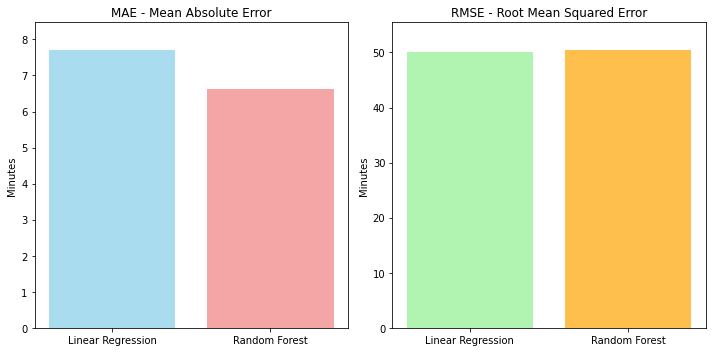

=== ANALYSE DES DÉLAIS DE PROPAGATION ===


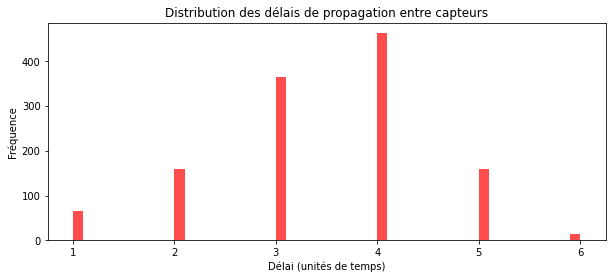

Délai moyen de propagation: 3.43
Délai max de propagation: 6.00

=== MODÈLE TRADITIONNEL AVEC DÉLAIS DE PROPAGATION ===
Features utilisées: ['distance_km', 'hour', 'weekday', 'month', 'is_weekend', 'passenger_count', 'avg_propagation_delay', 'max_propagation_delay', 'propagation_delay_ratio']
Train shape étendu: (182995, 9)


In [ ]:

# Target column to predict
target = 'trip_duration_min'

# Input features used for modeling
feature_cols = ['distance_km', 'hour', 'weekday', 'month', 'is_weekend', 'passenger_count']

X = df_taxi[feature_cols]
y = df_taxi[target]

print("\n \nA traditional traffic flow prediction model.")

# FIX NaN / Infinity issues
# Replace infinite values with NaN, then remove missing rows
df_taxi = df_taxi.replace([np.inf, -np.inf], np.nan)
df_taxi = df_taxi.dropna(subset=feature_cols + [target])

X = df_taxi[feature_cols]
y = df_taxi[target]

print("\n✔ After cleaning NaN and Inf:")
print(df_taxi.isna().sum())
print("Remaining rows:", len(df_taxi))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


# 1 Linear Regression -----------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("\nLinear Regression :")
print(f"MAE = {mae_lr:.2f} min")
print(f"RMSE = {rmse_lr:.2f} min")


# 2 Random Forest Regressor -----------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\nRandom Forest Regressor :")
print(f"MAE = {mae_rf:.2f} min")
print(f"RMSE = {rmse_rf:.2f} min")


# Performance Comparison Visualization -----------------------------
models = ['Linear Regression', 'Random Forest']
maes = [mae_lr, mae_rf]
rmses = [rmse_lr, rmse_rf]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(models, maes, alpha=0.7, color=['skyblue', 'lightcoral'])
plt.ylabel("Minutes")
plt.title("MAE - Mean Absolute Error")
plt.ylim(0, max(maes) * 1.1)

plt.subplot(1, 2, 2)
plt.bar(models, rmses, alpha=0.7, color=['lightgreen', 'orange'])
plt.ylabel("Minutes")
plt.title("RMSE - Root Mean Squared Error")
plt.ylim(0, max(rmses) * 1.1)

plt.tight_layout()
plt.show()


# Model using propagation-related features -----------------------------
def traditional_model_with_propagation(df_taxi, propagation_features):
    print("\n" + "="*60)
    print("=== TRADITIONAL MODEL WITH PROPAGATION DELAYS ===")
    print("="*60)
    
    # Create a modified dataframe to include propagation feature columns
    df_taxi_propagation = df_taxi.copy()

    # Compute propagation delay statistics
    df_taxi_propagation['avg_propagation_delay'] = np.mean(propagation_features)
    df_taxi_propagation['max_propagation_delay'] = np.max(propagation_features)
    
    # Ratio between distance and average delay
    df_taxi_propagation['propagation_delay_ratio'] = (
        df_taxi_propagation['distance_km'] / np.mean(propagation_features)
    )

    # Extended feature list
    feature_cols_extended = feature_cols + ['avg_propagation_delay', 
                                            'max_propagation_delay', 
                                            'propagation_delay_ratio']
    
    X_extended = df_taxi_propagation[feature_cols_extended]
    y = df_taxi_propagation[target]

    X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
        X_extended, y, test_size=0.2, random_state=42
    )
    
    print(f"Features used: {feature_cols_extended}")
    print(f"Extended train shape: {X_train_ext.shape}")
    
    # Train RF using extended feature set
    rf_model_ext = RandomForestRegressor(
        n_estimators=100, 
        max_depth=10, 
        random_state=42,
        n_jobs=-1
    )
    rf_model_ext.fit(X_train_ext, y_train_ext)

    y_pred_rf_ext = rf_model_ext.predict(X_test_ext)

    mae_rf_ext = mean_absolute_error(y_test_ext, y_pred_rf_ext)
    rmse_rf_ext = np.sqrt(mean_squared_error(y_test_ext, y_pred_rf_ext))
    
    print("\n Random Forest WITH propagation delays:")
    print(f"MAE = {mae_rf_ext:.2f} min")
    print(f"RMSE = {rmse_rf_ext:.2f} min")
    
    # Improvement vs base RF
    improvement_mae = ((mae_rf - mae_rf_ext) / mae_rf) * 100
    improvement_rmse = ((rmse_rf - rmse_rf_ext) / rmse_rf) * 100
    
    print(f"\n Improvement due to propagation modeling:")
    print(f"MAE: {improvement_mae:+.2f}%")
    print(f"RMSE: {improvement_rmse:+.2f}%")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols_extended,
        'importance': rf_model_ext.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n Top 5 feature importance:")
    print(feature_importance.head())
    
    # Visualization
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    comparison_data = {
        'Without Delay': [mae_rf, rmse_rf],
        'With Delay': [mae_rf_ext, rmse_rf_ext]
    }
    
    x = np.arange(2)
    width = 0.35
    
    plt.bar(x - width/2, comparison_data['Without Delay'], width, label='Without Delay', alpha=0.7)
    plt.bar(x + width/2, comparison_data['With Delay'], width, label='With Delay', alpha=0.7)
    
    plt.xlabel('Metrics')
    plt.ylabel('Minutes')
    plt.title('Performance Comparison')
    plt.xticks(x, ['MAE', 'RMSE'])
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    # Feature importance plot
    top_features = feature_importance.head(8)
    plt.barh(top_features['feature'], top_features['importance'], alpha=0.7)
    plt.xlabel('Importance')
    plt.title('Top Feature Importance')
    plt.gca().invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    return rf_model_ext, X_test_ext, y_test_ext, y_pred_rf_ext, feature_importance


try:
    # Analyze propagation delays from graph data (defined in dataset_analysis)
    propagation_delays = analyze_propagation_delays(df_pems, G)

    rf_model_ext, X_test_ext, y_test_ext, y_pred_rf_ext, feature_importance = traditional_model_with_propagation(
        df_taxi, propagation_delays
    )
    
    # Save performance results
    results_traditional = {
        'lr': {'mae': mae_lr, 'rmse': rmse_lr, 'predictions': y_pred_lr},
        'rf': {'mae': mae_rf, 'rmse': rmse_rf, 'predictions': y_pred_rf},
        'rf_with_delay': {'mae': mae_rf_ext, 'rmse': rmse_rf_ext, 'predictions': y_pred_rf_ext}
    }
    
except Exception as e:
    print(f" Cannot execute propagation section: {e}")
    print("Make sure analyze_propagation_delays() is defined in dataset_analysis.ipynb")
